In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("mexwell/crop-diseases-classification")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

Using Colab cache for faster access to the 'crop-diseases-classification' dataset.
Path to dataset files: /kaggle/input/crop-diseases-classification
Contents of base_path (/kaggle/input):
['crop-diseases-classification']
Contents of path (/kaggle/input/crop-diseases-classification):
['Data']


In [ ]:
import os

# Update path to match 'Data' directory found in the crop diseases dataset
data_path = os.path.join(path, 'Data')

# List subdirectories in Data (usually class labels)
if os.path.exists(data_path):
    print(f"Classes in dataset: {os.listdir(data_path)}")
else:
    print(f"Directory not found: {data_path}")

Classes in dataset: ['label_num_to_disease_map.json', 'train_images', 'train.csv']



--- Sample Images from Dataset (/kaggle/input/crop-diseases-classification/Data) ---
Found 17938 images. Displaying 6 samples:


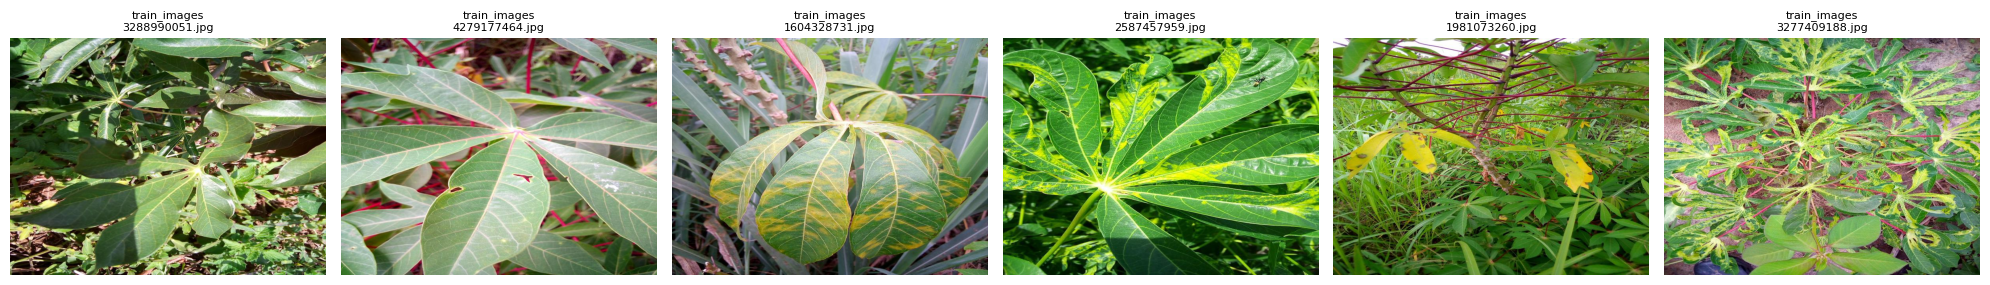

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images. Displaying {min(num_samples, len(all_image_paths))} samples:")

    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            # Display class name (parent directory) and filename
            label = os.path.basename(os.path.dirname(img_path))
            axes[i].set_title(f"{label}\n{os.path.basename(img_path)}", fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Use the correct Data path
data_path = os.path.join(path, 'Data')
print(f"\n--- Sample Images from Dataset ({data_path}) ---")
display_sample_images(data_path)

In [ ]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split

# Sử dụng original_df đã được tải từ train.csv ở các bước trước
# Đảm bảo chúng ta có dữ liệu hợp lệ
if 'original_df' in globals() and not original_df.empty:
    df = original_df.copy()

    # Chia tập dữ liệu theo tỷ lệ 8/2 (80% train, 20% test)
    # stratify giúp giữ nguyên tỷ lệ các lớp bệnh
    train_df, test_df = train_test_split(
        df,
        test_size=0.2,
        random_state=42,
        stratify=df['label']
    )

    print(f"Tổng số mẫu trong bộ dữ liệu: {len(df)}")
    print(f"Số lượng tập huấn luyện (Train): {len(train_df)}")
    print(f"Số lượng tập kiểm tra (Test): {len(test_df)}")

    print("\n5 dòng đầu tiên của tập Train:")
    display(train_df.head())
else:
    print("Lỗi: Không tìm thấy original_df hoặc dữ liệu rỗng. Vui lòng kiểm tra lại bước đọc file CSV.")

Tổng số mẫu trong bộ dữ liệu: 21397
Số lượng tập huấn luyện (Train): 17117
Số lượng tập kiểm tra (Test): 4280

5 dòng đầu tiên của tập Train:


,image_id,label
1715,1300823152.jpg,4
11830,3116613979.jpg,3
8621,2530012971.jpg,3
3849,1686186154.jpg,3
12924,3312736716.jpg,1


In [ ]:
import tensorflow as tf

# Check GPU availability
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
if tf.test.gpu_device_name():
    print('Default GPU Device: {}'.format(tf.test.gpu_device_name()))
else:
    print("Please install GPU version of TF or check your Colab Runtime settings (Runtime -> Change runtime type).")

Num GPUs Available:  1
Default GPU Device: /device:GPU:0


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras import layers, models, optimizers
import os

# Configuration
IMG_SIZE = (299, 299)
BATCH_SIZE = 32
IMAGE_DIR = os.path.join(data_path, 'train_images')

# Data Augmentation and Generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Convert label to string for flow_from_dataframe
train_df['label'] = train_df['label'].astype(str)
test_df['label'] = test_df['label'].astype(str)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=IMAGE_DIR,
    x_col="image_id",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

validation_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=IMAGE_DIR,
    x_col="image_id",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Build InceptionV3 Model
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(299, 299, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(5, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Use history_obj to avoid name collision
history_obj = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Found 14342 validated image filenames belonging to 5 classes.
Found 3596 validated image filenames belonging to 5 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:918: UserWarning: Found 2775 invalid image filename(s) in x_col="image_id". These filename(s) will be ignored.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:918: UserWarning: Found 684 invalid image filename(s) in x_col="image_id". These filename(s) will be ignored.
  warnings.warn(


Epoch 1/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 423s 910ms/step - accuracy: 0.6328 - loss: 1.0260 - val_accuracy: 0.6677 - val_loss: 0.8553
Epoch 2/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 395s 879ms/step - accuracy: 0.6579 - loss: 0.9165 - val_accuracy: 0.6980 - val_loss: 0.8422
Epoch 3/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 390s 869ms/step - accuracy: 0.6664 - loss: 0.8982 - val_accuracy: 0.6877 - val_loss: 0.8145
Epoch 4/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 394s 879ms/step - accuracy: 0.6696 - loss: 0.8808 - val_accuracy: 0.7022 - val_loss: 0.8137
Epoch 5/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 398s 887ms/step - accuracy: 0.6648 - loss: 0.8851 - val_accuracy: 0.6994 - val_loss: 0.8164
Epoch 6/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 396s 883ms/step - accuracy: 0.6724 - loss: 0.8689 - val_accuracy: 0.7041 - val_loss: 0.7976
Epoch 7/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 396s 882ms/step - accuracy: 0.6761 - loss: 0.8578 - val_accuracy: 0.7058 - val_loss: 0.7733
Epoch 8/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 394s 879ms/step - accuracy: 0.6775 -

In [ ]:
# Summary of Training Results using history_obj
final_train_accuracy = history_obj.history['accuracy'][-1]
final_val_accuracy = history_obj.history['val_accuracy'][-1]

print(f"--- Training Summary ---")
print(f"Final Training Accuracy: {final_train_accuracy:.4f}")
print(f"Final Validation Accuracy: {final_val_accuracy:.4f}")
model.summary()

--- Training Summary ---
Final Training Accuracy: 0.6764
Final Validation Accuracy: 0.7113


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,380,273 (89.19 MB)

 Trainable params: 525,829 (2.01 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

 Optimizer params: 1,051,660 (4.01 MB)

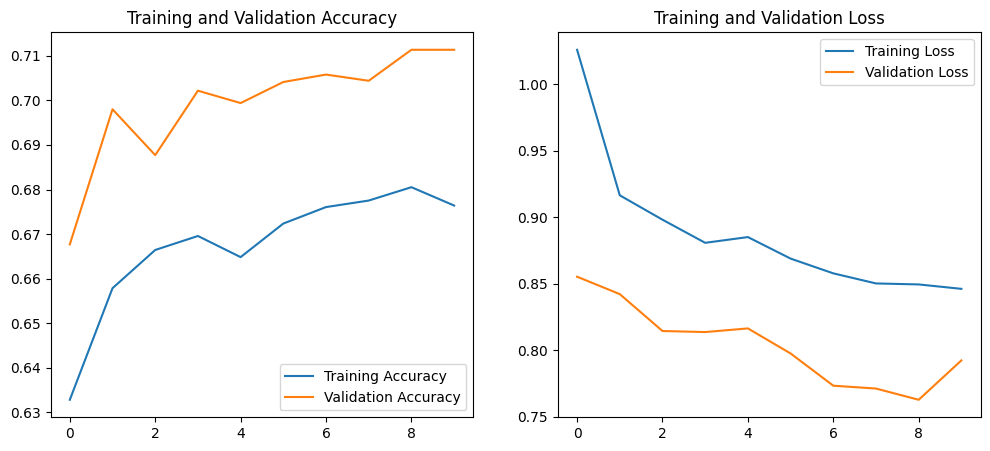

In [ ]:
import matplotlib.pyplot as plt

# Plot Training and Validation curves using history_obj
acc = history_obj.history['accuracy']
val_acc = history_obj.history['val_accuracy']
loss = history_obj.history['loss']
val_loss = history_obj.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(loc='lower right')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend(loc='upper right')

plt.show()